In [1]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba\
                    , compute_all_distances_batch, adc_distances_all_optimized, lsq_alpha_from_codes \
                    , lsq_dot_tables_vectorized, lsq_distances_batch_numba
  



In [ ]:
# root = "mnthdd" #thalia 
root = "data" #urania 
data_fp = f"/{root}/cpanourg/2-hdvc/"

dataset_name = 'deep'

if dataset_name == 'gist':
    # Loading the GIST dataset
    db = np.array(read_fvecs(f'{data_fp}data/gist/gist_base.fvecs'))
    qr = np.array(read_fvecs(f'{data_fp}data/gist/gist_query.fvecs'))

elif dataset_name == 'deep':
    db = np.fromfile(f'{data_fp}data/deep1b/dataset/deep1b-96-100m.bin', dtype=np.float32).reshape(100_000_000, -1)
    qr = np.fromfile(f'{data_fp}data/deep1b/queries/queries-hard10p-deep1b-len96-1000.bin', np.float32).reshape(1000, -1)

train_size = 100_000
test_size = 1_000_000

idxs = np.random.choice(db.shape[0], train_size + test_size, replace=False)
train_idxs, test_idxs = idxs[:train_size], idxs[train_size:]

train_db, test_db = db[train_idxs], db[test_idxs]


nb = test_db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = test_db.shape[1]  # Dimensionality of the vectors

print(f"Database shape: {test_db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

# Ensure data is float32 for FAISS
train_db = train_db.astype(np.float32)
test_db = test_db.astype(np.float32)
qr = qr.astype(np.float32)

Database shape: (1000000, 96)
Query shape: (1000, 96)
Dimension: 96


In [3]:
# #hps
# sampling_method = 'random'
# train_size_ratio = 0.1
# train_size = int(db.shape[0] * train_size_ratio)  # Number of training vectors
bits_per_vector = 96
k = 100  # Number of nearest neighbors


nbits = 8  # 2^nbits centroids per subquantizer
n_subquantizers = bits_per_vector // nbits  # Number of subquantizers
ksub = 1 << nbits  # 256 centroids per subquantizer

if bits_per_vector % nbits != 0:
    print('nbits and n_subquantizers should multiply to equal bits_per_vector')

In [4]:
start = time.time()

# lsq = faiss.LocalSearchQuantizer(dim, n_subquantizers, nbits)
lsq = faiss.LocalSearchQuantizer(
    dim, n_subquantizers, nbits,
    faiss.LocalSearchQuantizer.ST_norm_qint8,  # LSQ++
)

# if sampling_method == 'random':
#     num_samples = min(int(train_size_ratio * nb), nb)  
#     training_data = db[np.random.choice(nb, num_samples, replace=False)]
#     print(f"Training LSQ on {num_samples} random samples from the database.")


lsq.train(train_db)

end = time.time()

lsq_train_time = np.round(end - start, 2)
print(f"Time to train LSQ: {lsq_train_time} seconds")
print("is_trained:", lsq.is_trained)

Time to train LSQ: 87.17 seconds
is_trained: True


In [5]:
start = time.time()
db_lsq = lsq.compute_codes(test_db)
end = time.time()
codes_time = np.round(end - start, 2)

print(f"Time to compute codes for the database: {codes_time} seconds")
print(f"Codes shape: {db_lsq.shape}")

Time to compute codes for the database: 56.17 seconds
Codes shape: (1000000, 13)


In [6]:
db_lsq

array([[245, 166, 226, ..., 133,  73, 148],
       [164, 205, 167, ..., 110, 164, 125],
       [  0, 249, 104, ..., 221, 106,  80],
       ...,
       [ 30, 201,  88, ...,  37, 138,  70],
       [ 31,  36,  50, ..., 120,  96,  71],
       [111,  76, 252, ..., 171, 232, 118]], dtype=uint8)

In [10]:
sample_queries=1000
sample_db=10000

q_idx = np.random.choice(nq, min(sample_queries, nq), replace=False)
db_idx = np.random.choice(nb, min(sample_db, nb), replace=False)

qr_sample = qr[q_idx]
db_sample = test_db[db_idx]


# Build codebooks (m, ksub, d) from a trained LSQ (uniform nbits)
table = faiss.vector_to_array(lsq.codebooks).reshape(-1, dim)
codebooks = table.reshape(n_subquantizers, (1 << nbits), dim)

start = time.time()
# Precompute alpha for the DB
alpha = lsq_alpha_from_codes(codebooks, db_lsq[db_idx, :n_subquantizers])             # (nb,)

# Build per-query DOT tables
dot_tables = lsq_dot_tables_vectorized(qr_sample, codebooks)      # (nq, m, ksub)

# Query norms
qnorms = np.einsum('ij,ij->i', qr_sample, qr_sample).astype(np.float32)  # (nq,)

# Distances (nq, nb)
all_distances = lsq_distances_batch_numba(dot_tables, db_lsq[db_idx], alpha, qnorms)
end = time.time()
dist_time = np.round(end - start, 2)


In [11]:
all_distances  # (nq, nb)

array([[106.95347,  86.88206, 101.90852, ...,  81.99963,  95.39996,
         79.28149],
       [ 88.78757,  77.00702, 104.41936, ...,  88.25615, 100.95863,
         80.6785 ],
       [ 97.77631,  93.67783, 101.62663, ...,  95.40423, 103.10355,
         87.48595],
       ...,
       [ 94.38247,  76.8484 , 104.67138, ...,  94.33728,  93.33423,
         80.83901],
       [ 99.04546,  79.54917, 106.20599, ..., 107.39707,  97.36422,
         91.9896 ],
       [ 95.42317,  92.46906,  98.62554, ...,  85.11824,  93.02906,
         85.71706]], dtype=float32)

In [12]:

# Exact distances with cdist
t0 = time.time()
exact_sample = cdist(qr_sample, db_sample, metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0
time.time() - t0
print(f"Time to compute exact distances: {cdist_time} seconds")

Time to compute exact distances: 0.5071101188659668 seconds


In [13]:
exact_sample

array([[114.77766, 108.32389, 113.97955, ..., 101.4518 , 101.50454,
        101.61415],
       [101.18117, 100.09758, 114.82098, ..., 101.70752, 111.40695,
        106.52381],
       [105.87174, 112.26266, 105.97095, ..., 105.52201, 114.28925,
        108.90321],
       ...,
       [103.98506,  95.72018, 111.51548, ..., 110.42075,  98.23972,
        105.18277],
       [107.04937,  97.6405 , 113.04943, ..., 122.1078 , 100.42934,
        115.01775],
       [107.07017, 111.0415 , 105.20739, ...,  99.93374, 101.81194,
        107.25645]], dtype=float32)

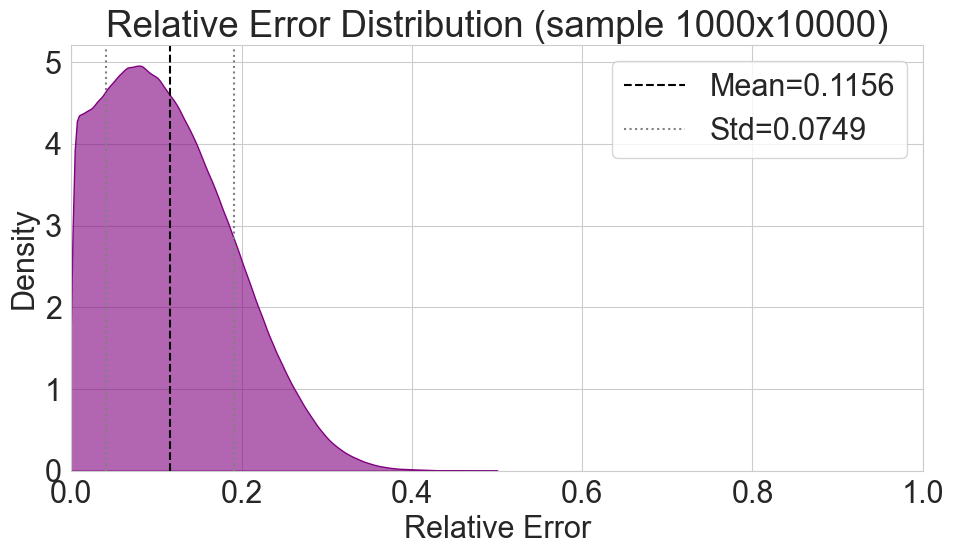

[cdist] sample 1000 queries x 10000 DB: 0.507s
Mean relative error=0.115602, Std=0.074928


In [ ]:

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(all_distances - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile(f'/data/cpanourg/2-hdvc/results/lsq_pp/{dataset_name}/rel_error.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [15]:

summary = {
    "method": "LSQ",
    "dataset": dataset_name,
    "nq": nq,
    "nb": nb,
    "nb_sample": len(db_idx),
    "dim": dim,
    "n_subquantizers": n_subquantizers,
    "nbits": nbits,
    "bits_per_vector": n_subquantizers * nbits,
    # "k": k,
    # "train_ratio": train_size_ratio,
    "train_size": train_size,
    "train_time_s": float(lsq_train_time),
    "encoding_time_s": float(codes_time),
    "distance_table_time_s": float(0),
    "cdist_time_s": float(cdist_time),
    "adc_time_s": float(dist_time),
    "rel_error_mean": float(mean_rel),
    "rel_error_std": float(std_rel),

}
csv_path=f"/{root}/cpanourg/2-hdvc/results/{dataset_name}_adc_vs_exact_eval.csv"

need_header = not Path(csv_path).exists() or Path(csv_path).stat().st_size == 0
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    if need_header:
        writer.writeheader()
    writer.writerow(summary)


In [16]:
import pandas as pd

pd.read_csv(f"/{root}/cpanourg/2-hdvc/results/{dataset_name}_adc_vs_exact_eval.csv").round(4)


,method,dataset,nq,nb,nb_sample,dim,n_subquantizers,nbits,bits_per_vector,train_size,train_time_s,encoding_time_s,distance_table_time_s,cdist_time_s,adc_time_s,rel_error_mean,rel_error_std
0,PQ,deep,1000,1000000,10000,96,12,8,96,100000,0.8817,0.2155,0.1199,0.5012,1.6657,0.2248,0.0781
1,OPQ,deep,1000,1000000,10000,96,12,8,96,100000,11.6713,0.2521,0.1687,0.5126,0.8565,0.1704,0.0968
2,LSQ,deep,1000,1000000,10000,96,12,8,96,100000,87.1700,56.1700,0.0000,0.5071,0.8000,0.1156,0.0749
